In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
import os
import glob
import json
import random
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import rasterio
from tqdm import tqdm

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt


In [ ]:
DATA_ROOT = "/kaggle/input/datasets/abdulhamedeid/yieldsat-private/Raw"

N_DATES = 20
RANDOM_SEED = 42
LABEL_NAMES = ["wheat", "corn", "other"]
REFLECTANCE_BANDS = [
    "B01",
    "B02",
    "B03",
    "B04",
    "B05",
    "B06",
    "B07",
    "B08",
    "B8A",
    "B09",
    "B11",
    "B12",
]
VALID_SCL_CLASSES = [4, 5, 6, 7]
VALID_FRACTION_INDEX = len(REFLECTANCE_BANDS)
FEATURE_NAMES = REFLECTANCE_BANDS + ["valid_fraction"]

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


In [ ]:
field_dirs = glob.glob(os.path.join(DATA_ROOT, "*", "*", "*"))

print("Number of field folders:", len(field_dirs))
print(field_dirs[:3])

Number of field folders: 2173
['/kaggle/input/datasets/abdulhamedeid/yieldsat-private/Raw/Uruguay/Uruguay/Uruguay_DUP4_farm10_field515_soybean_2022', '/kaggle/input/datasets/abdulhamedeid/yieldsat-private/Raw/Uruguay/Uruguay/Uruguay_DUP4_farm10_field436_soybean_2018', '/kaggle/input/datasets/abdulhamedeid/yieldsat-private/Raw/Uruguay/Uruguay/Uruguay_DUP4_farm9_field269_soybean_2018']


In [ ]:
fields_by_crop = defaultdict(list)
metadata_by_field = {}

for field_dir in field_dirs:
    meta_files = glob.glob(os.path.join(field_dir, "metadata-*.json"))
    
    if len(meta_files) == 0:
        continue
    
    with open(meta_files[0], "r") as f:
        meta = json.load(f)
    
    crop = meta.get("crop", "").lower()
    
    fields_by_crop[crop].append(field_dir)
    metadata_by_field[field_dir] = meta

for crop, fields in fields_by_crop.items():
    print(crop, len(fields))

soybean 1305
wheat 454
corn 303
rapeseed 111


In [ ]:
wheat_fields = fields_by_crop["wheat"]
corn_fields = fields_by_crop["corn"]

soybean_sample = random.sample(fields_by_crop["soybean"], 400)
rapeseed_sample = random.sample(fields_by_crop["rapeseed"], 100)

selected_fields = (
    wheat_fields
    + corn_fields
    + soybean_sample
    + rapeseed_sample
)

random.shuffle(selected_fields)

print("Selected fields:", len(selected_fields))
print("Wheat:", len(wheat_fields))
print("Corn:", len(corn_fields))
print("Soybean as other:", len(soybean_sample))
print("Rapeseed as other:", len(rapeseed_sample))

Selected fields: 1257
Wheat: 454
Corn: 303
Soybean as other: 400
Rapeseed as other: 100


In [ ]:
def get_label(crop):
    crop = crop.lower()
    if crop == "wheat":
        return 0
    elif crop == "corn":
        return 1
    else:
        return 2

In [ ]:
LABEL_NAMES = ["wheat", "corn", "other"]

In [ ]:
def sample_dates(s2_files, n_dates=20):
    s2_files = sorted(s2_files)

    if len(s2_files) == 0:
        return []

    if len(s2_files) >= n_dates:
        idx = np.linspace(0, len(s2_files) - 1, n_dates).astype(int)
        return [s2_files[i] for i in idx]

    padded = s2_files.copy()

    while len(padded) < n_dates:
        padded.append(s2_files[-1])

    return padded


def find_matching_scl(s2_path):
    scl_path = (
        s2_path
        .replace("/s2_images/", "/scl_masks/")
        .replace("S2_L2A_", "S2_L2A_SCL_")
    )

    if os.path.exists(scl_path):
        return scl_path

    return None


def read_reflectance_bands_with_scl(s2_path):
    with rasterio.open(s2_path) as src:
        img = src.read().astype("float32") / 10000.0

    img[img <= 0] = np.nan

    scl_path = find_matching_scl(s2_path)
    valid_fraction = 1.0

    if scl_path is not None:
        with rasterio.open(scl_path) as src:
            scl = src.read(1)

        valid_mask = np.isin(scl, VALID_SCL_CLASSES)
        valid_fraction = float(valid_mask.mean())
        img[:, ~valid_mask] = np.nan

    band_means = []

    for b in range(img.shape[0]):
        band = img[b]

        if np.all(np.isnan(band)):
            band_means.append(np.nan)
        else:
            band_means.append(float(np.nanmean(band)))

    return np.array(band_means, dtype="float32"), np.float32(valid_fraction)


In [ ]:
X_list = []
y_list = []
rows = []

for field_dir in tqdm(selected_fields):
    meta = metadata_by_field[field_dir]

    crop = meta["crop"].lower()
    label = get_label(crop)

    s2_dir = os.path.join(field_dir, "s2_images")
    s2_files = glob.glob(os.path.join(s2_dir, "*.tif"))

    if len(s2_files) == 0:
        continue

    selected_s2_files = sample_dates(s2_files, N_DATES)

    seq = []
    ok = True

    for s2_file in selected_s2_files:
        try:
            band_means, valid_fraction = read_reflectance_bands_with_scl(s2_file)
            timestep_features = np.concatenate(
                [band_means, np.array([valid_fraction], dtype="float32")]
            )
            seq.append(timestep_features)
        except Exception:
            ok = False
            break

    if not ok:
        continue

    seq = np.stack(seq).astype("float32")

    X_list.append(seq)
    y_list.append(label)

    adm_units = meta.get("adm_units", {})
    country = adm_units.get("country", field_dir.split("/")[-3])
    year = meta.get("year")

    rows.append({
        "field_dir": field_dir,
        "country": country,
        "year": year,
        "country_year": f"{country}_{year}",
        "farm_identifier": meta.get("farm_identifier"),
        "crop": crop,
        "label": label,
        "n_s2_images": len(s2_files),
        "n_features": seq.shape[1],
    })

X = np.stack(X_list)
y = np.array(y_list)
meta_df = pd.DataFrame(rows)

print("X shape:", X.shape)
print("y shape:", y.shape)
print(meta_df["crop"].value_counts())
print(meta_df["label"].value_counts())
print(meta_df["country_year"].nunique(), "unique country_year groups")
print(meta_df["n_features"].value_counts())


In [ ]:
feature_names = FEATURE_NAMES
reflectance_feature_count = len(REFLECTANCE_BANDS)

print("Reflectance bands:", REFLECTANCE_BANDS)
print("Feature names:", feature_names)
print("Reflectance feature count:", reflectance_feature_count)


In [ ]:
def fill_nan_temporal_reflectance(X, reflectance_feature_count):
    X_filled = X.copy()

    for i in range(X.shape[0]):
        for b in range(reflectance_feature_count):
            s = pd.Series(X[i, :, b])
            s = s.interpolate(method="linear", limit_direction="both")

            if s.isna().any():
                s = s.fillna(s.median())

            X_filled[i, :, b] = s.values

    return X_filled

print("NaNs before:", np.isnan(X).sum())

X_clean = fill_nan_temporal_reflectance(X, reflectance_feature_count)

print("NaNs after temporal fill:", np.isnan(X_clean).sum())

if np.isnan(X_clean[:, :, :reflectance_feature_count]).sum() > 0:
    global_medians = np.nanmedian(X_clean[:, :, :reflectance_feature_count], axis=(0, 1))

    for b in range(reflectance_feature_count):
        X_clean[:, :, b] = np.where(
            np.isnan(X_clean[:, :, b]),
            global_medians[b],
            X_clean[:, :, b]
        )

X_clean[:, :, VALID_FRACTION_INDEX] = np.nan_to_num(
    X_clean[:, :, VALID_FRACTION_INDEX],
    nan=0.0,
)
X_clean[:, :, VALID_FRACTION_INDEX] = np.clip(
    X_clean[:, :, VALID_FRACTION_INDEX],
    0.0,
    1.0,
)

print("NaNs final:", np.isnan(X_clean).sum())
print("Reflectance min:", np.nanmin(X_clean[:, :, :reflectance_feature_count]))
print("Reflectance max:", np.nanmax(X_clean[:, :, :reflectance_feature_count]))
print("Valid fraction min:", np.nanmin(X_clean[:, :, VALID_FRACTION_INDEX]))
print("Valid fraction max:", np.nanmax(X_clean[:, :, VALID_FRACTION_INDEX]))


In [ ]:
df_sample = pd.DataFrame(X_clean[0], columns=feature_names)
df_sample["time_step"] = range(1, N_DATES + 1)
df_sample["crop"] = meta_df.iloc[0]["crop"]
df_sample["label"] = meta_df.iloc[0]["label"]

df_sample


In [ ]:
group_labels = meta_df["country_year"].values

outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED,
)

train_idx, test_idx = next(outer_cv.split(X_clean, y, groups=group_labels))

X_train, X_test = X_clean[train_idx], X_clean[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
train_group_labels = group_labels[train_idx]

print("Train:", X_train.shape, Counter(y_train))
print("Test:", X_test.shape, Counter(y_test))
print("Train groups:", len(np.unique(train_group_labels)))
print("Test groups:", len(np.unique(group_labels[test_idx])))


In [ ]:
inner_cv = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=RANDOM_SEED,
)

tr_idx, val_idx = next(
    inner_cv.split(X_train, y_train, groups=train_group_labels)
)

X_tr, X_val = X_train[tr_idx], X_train[val_idx]
y_tr, y_val = y_train[tr_idx], y_train[val_idx]

print("Train final:", X_tr.shape, Counter(y_tr))
print("Validation:", X_val.shape, Counter(y_val))
print("Validation groups:", len(np.unique(train_group_labels[val_idx])))


In [ ]:
scaler = StandardScaler()

X_tr_2d = X_tr.reshape(-1, X_tr.shape[-1])
X_val_2d = X_val.reshape(-1, X_val.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

X_tr_scaled = scaler.fit_transform(X_tr_2d).reshape(X_tr.shape)
X_val_scaled = scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test_2d).reshape(X_test.shape)

print("X_tr_scaled:", X_tr_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("Scaled feature count:", X_tr_scaled.shape[-1])


In [ ]:
n_timesteps = X_tr_scaled.shape[1]
n_features = X_tr_scaled.shape[2]
n_classes = len(np.unique(y))

model = models.Sequential([
    layers.Input(shape=(n_timesteps, n_features)),

    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(n_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_tr_scaled,
    y_tr,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5449 - loss: 0.9698 - val_accuracy: 0.6445 - val_loss: 0.8188
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7011 - loss: 0.7148 - val_accuracy: 0.7826 - val_loss: 0.5938
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7934 - loss: 0.5299 - val_accuracy: 0.7980 - val_loss: 0.4832
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8315 - loss: 0.4348 - val_accuracy: 0.8363 - val_loss: 0.4257
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8733 - loss: 0.3427 - val_accuracy: 0.8082 - val_loss: 0.4692
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8733 - loss: 0.3056 - val_accuracy: 0.8491 - val_loss: 0.4125
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8930 - loss: 0.2702 - val_accuracy: 0.8568 - val_loss: 0.3928
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9127 - loss: 0.2137 - val_accuracy: 0.

In [ ]:
probs = model.predict(X_test_scaled)
pred = np.argmax(probs, axis=1)

print("LSTM Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(
    classification_report(
        y_test,
        pred,
        target_names=LABEL_NAMES
    )
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
LSTM Accuracy: 0.9245283018867925
[[12  0  2]
 [ 0 19  0]
 [ 2  0 18]]
              precision    recall  f1-score   support

       wheat       0.86      0.86      0.86        14
        corn       1.00      1.00      1.00        19
       other       0.90      0.90      0.90        20

    accuracy                           0.92        53
   macro avg       0.92      0.92      0.92        53
weighted avg       0.92      0.92      0.92        53



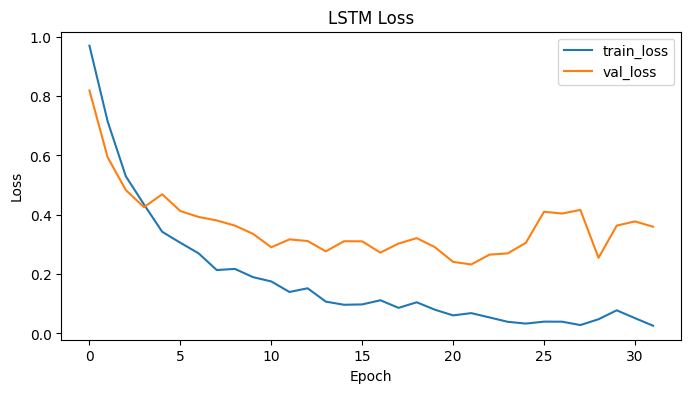

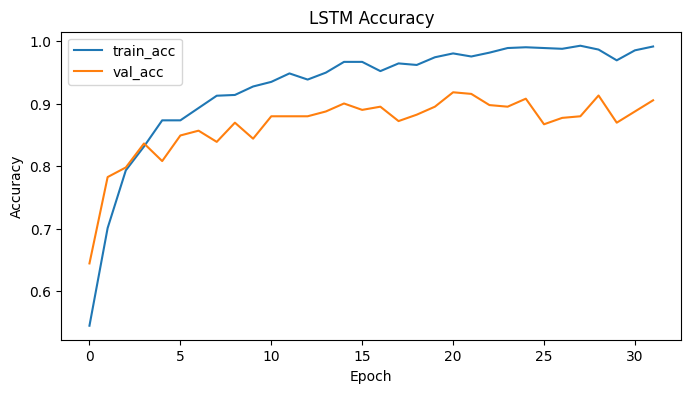

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
from xgboost import XGBClassifier

X_tr_flat = X_tr_scaled.reshape(X_tr_scaled.shape[0], -1)
X_val_flat = X_val_scaled.reshape(X_val_scaled.shape[0], -1)
X_test_flat = X_test_scaled.reshape(X_test_scaled.shape[0], -1)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    random_state=RANDOM_SEED,
)

xgb.fit(
    X_tr_flat,
    y_tr,
    eval_set=[(X_val_flat, y_val)],
    verbose=False,
)

xgb_pred = xgb.predict(X_test_flat)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=LABEL_NAMES,
    )
)


In [ ]:
import os
import json
import shutil
import joblib

SAVE_DIR = "saved_reflectance_baseline_lstm_model"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(os.path.join(SAVE_DIR, "lstm_crop_classifier.keras"))
joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler.pkl"))
joblib.dump(feature_names, os.path.join(SAVE_DIR, "feature_names.pkl"))
joblib.dump(LABEL_NAMES, os.path.join(SAVE_DIR, "label_names.pkl"))

config = {
    "model_name": "reflectance_baseline_lstm",
    "task": "field_level_crop_classification",
    "labels": LABEL_NAMES,
    "n_timesteps": int(X_tr_scaled.shape[1]),
    "n_features": int(X_tr_scaled.shape[2]),
    "feature_names": feature_names,
    "input_shape": [int(X_tr_scaled.shape[1]), int(X_tr_scaled.shape[2])],
}

with open(os.path.join(SAVE_DIR, "config.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

np.save("X_wheat_corn_other_reflectance_valid_fraction.npy", X_clean)
np.save("y_wheat_corn_other.npy", y)
meta_df.to_csv("metadata_wheat_corn_other_country_year.csv", index=False)

shutil.make_archive(SAVE_DIR, "zip", SAVE_DIR)

print("Saved reflectance baseline outputs and LSTM package:")
print(sorted(os.listdir(SAVE_DIR)))
print(f"{SAVE_DIR}.zip")


In [ ]:
print(meta_df["country_year"].value_counts().sort_index())


In [ ]:
print("Unique country_year groups:", meta_df["country_year"].nunique())
